# 4.2: Notebook-Complete model evaluation workflow

Dataset: Handwritten Digits Recognition (8×8 pixel images of digits 0–9)

This notebook demonstrates:
1. Cross-validation for reliable evaluation
2. Hyperparameter tuning with GridSearchCV
3. Multiple evaluation metrics
4. Fair model comparison

In [1]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     cross_val_predict, GridSearchCV,
                                     StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Set random seed for reproducibility
np.random.seed(42)

## Step 1: Load and explore the dataset

In [2]:
# Load the digits dataset
digits = load_digits()
X = digits.data
y = digits.target

print(f"\nDataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")

# Check class distribution
print("\nClass distribution:")
for digit in range(10):
    count = np.sum(y == digit)
    percentage = (count / len(y)) * 100
    print(f"  Digit {digit}: {count} samples ({percentage:.1f}%)")


Dataset shape: (1797, 64)
Number of samples: 1797
Number of features: 64
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]

Class distribution:
  Digit 0: 178 samples (9.9%)
  Digit 1: 182 samples (10.1%)
  Digit 2: 177 samples (9.8%)
  Digit 3: 183 samples (10.2%)
  Digit 4: 181 samples (10.1%)
  Digit 5: 182 samples (10.1%)
  Digit 6: 181 samples (10.1%)
  Digit 7: 179 samples (10.0%)
  Digit 8: 174 samples (9.7%)
  Digit 9: 180 samples (10.0%)


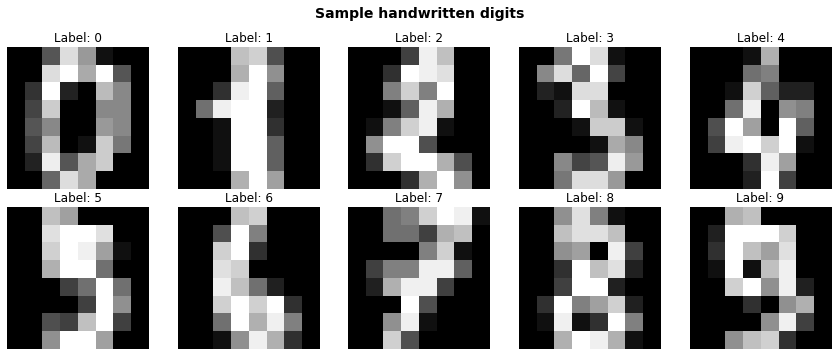

In [3]:
# Visualise some example digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Sample handwritten digits', fontsize=14, fontweight='bold')
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Create a train-test split

In [4]:
# Split data — keeping 20% for final testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


Training set size: 1437 samples
Test set size: 360 samples


> **Important:** The training set will be used for cross-validation and tuning. The test set will only be used at the very end for final evaluation.

## Step 3: Demonstrate the problem with single splits

In [5]:
print("\n" + "=" * 70)
print("Step 3: Why single train-test splits are unreliable")
print("=" * 70)

# Train a simple model with different random splits
model = LogisticRegression(max_iter=10000)
scores_single_split = []

print("\nTrying 10 different random splits of the same data:")
for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_train, y_train, test_size=0.2, random_state=seed, stratify=y_train
    )
    model.fit(X_tr, y_tr)
    score = model.score(X_te, y_te)
    scores_single_split.append(score)
    print(f"  Split {seed}: Accuracy = {score:.3f}")

print(f"\nMean accuracy: {np.mean(scores_single_split):.3f}")
print(f"Std deviation: {np.std(scores_single_split):.3f}")
print(f"Range: {np.min(scores_single_split):.3f} to {np.max(scores_single_split):.3f}")


Step 3: Why single train-test splits are unreliable

Trying 10 different random splits of the same data:
  Split 0: Accuracy = 0.941
  Split 1: Accuracy = 0.965
  Split 2: Accuracy = 0.962
  Split 3: Accuracy = 0.962
  Split 4: Accuracy = 0.958
  Split 5: Accuracy = 0.944
  Split 6: Accuracy = 0.969
  Split 7: Accuracy = 0.958
  Split 8: Accuracy = 0.972
  Split 9: Accuracy = 0.962

Mean accuracy: 0.959
Std deviation: 0.009
Range: 0.941 to 0.972


The score varies across splits, simply due to which samples happen to fall in the test set. A single split cannot reliably answer which score represents the model's true performance. This is the motivation for cross-validation, introduced in the next step.

## Step 4: Cross-validation for reliable evaluation

In [6]:
# Create a pipeline with preprocessing
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=10000, random_state=42))
])

# Perform 5-fold cross-validation
print("\nPerforming 5-fold cross-validation on training data...")
cv_scores = cross_val_score(pipeline_lr, X_train, y_train, cv=5)

print("\nCross-validation results:")
for fold, score in enumerate(cv_scores, 1):
    print(f"  Fold {fold}: {score:.3f}")

print(f"\nMean CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")
print("\nCross-validation gives a more reliable estimate of performance.")
print("The standard deviation shows how consistent the model is across folds.")


Performing 5-fold cross-validation on training data...

Cross-validation results:
  Fold 1: 0.979
  Fold 2: 0.972
  Fold 3: 0.979
  Fold 4: 0.969
  Fold 5: 0.948

Mean CV accuracy: 0.969 (+/- 0.012)

Cross-validation gives a more reliable estimate of performance.
The standard deviation shows how consistent the model is across folds.


In [7]:
# Compare different k values
print("\n" + "-" * 70)
print("Comparing different numbers of folds:")
print("-" * 70)

for k in [3, 5, 10]:
    scores = cross_val_score(pipeline_lr, X_train, y_train, cv=k)
    print(f"\nk={k} folds:")
    print(f"  Mean accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")


----------------------------------------------------------------------
Comparing different numbers of folds:
----------------------------------------------------------------------

k=3 folds:
  Mean accuracy: 0.965 (+/- 0.010)

k=5 folds:
  Mean accuracy: 0.969 (+/- 0.012)

k=10 folds:
  Mean accuracy: 0.968 (+/- 0.012)


## Step 5: Hyperparameter tuning with GridSearchCV

In [8]:
# Example 1: Tune K-Nearest Neighbors
print("\nExample 1: Tuning K-Nearest Neighbors")
print("-" * 70)

pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier())
])

param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance']
}

grid_search_knn = GridSearchCV(
    pipeline_knn,
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    verbose=1
)

print("\nSearching for best hyperparameters...")
grid_search_knn.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_knn.best_params_}")
print(f"Best CV score: {grid_search_knn.best_score_:.3f}")


Example 1: Tuning K-Nearest Neighbors
----------------------------------------------------------------------

Searching for best hyperparameters...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best parameters: {'classifier__n_neighbors': 5, 'classifier__weights': 'uniform'}
Best CV score: 0.975


In [9]:
# Example 2: Tune Decision Tree
# Note: StandardScaler has no effect on Decision Trees — trees split on
# thresholds rather than distances, so feature scale does not influence
# the result. It is included here to keep the pipeline structure
# consistent with the other models in this notebook.

print("\nExample 2: Tuning Decision Tree")
print("-" * 70)

pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid_dt = {
    'classifier__max_depth': [5, 10, 15, 20, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    verbose=1
)

print("\nSearching for best hyperparameters...")
grid_search_dt.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_dt.best_params_}")
print(f"Best CV score: {grid_search_dt.best_score_:.3f}")


Example 2: Tuning Decision Tree
----------------------------------------------------------------------

Searching for best hyperparameters...
Fitting 5 folds for each of 45 candidates, totalling 225 fits

Best parameters: {'classifier__max_depth': 15, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV score: 0.851


In [10]:
# Example 3: Tune Random Forest

# Note: StandardScaler has no effect on Random Forest — like a single
# Decision Tree, Random Forest splits on thresholds rather than distances,
# so feature scale does not influence the result. It is included here to
# keep the pipeline structure consistent with the other models in this notebook.
print("\nExample 3: Tuning Random Forest")
print("-" * 70)

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5]
}

grid_search_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1
)

print("\nSearching for best hyperparameters...")
grid_search_rf.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_rf.best_params_}")
print(f"Best CV score: {grid_search_rf.best_score_:.3f}")


Example 3: Tuning Random Forest
----------------------------------------------------------------------

Searching for best hyperparameters...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best CV score: 0.976


In [11]:
# Example 4: Tune Logistic Regression
print("\nExample 4: Tuning Logistic Regression")
print("-" * 70)

pipeline_lr_tuned = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_lr = {
    'classifier__C': [0.1, 1, 10],
    'classifier__solver': ['lbfgs']
}

grid_search_lr = GridSearchCV(
    pipeline_lr_tuned,
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    verbose=1
)

print("\nSearching for best hyperparameters...")
grid_search_lr.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_lr.best_params_}")
print(f"Best CV score: {grid_search_lr.best_score_:.3f}")


Example 4: Tuning Logistic Regression
----------------------------------------------------------------------

Searching for best hyperparameters...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best parameters: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Best CV score: 0.969


## Step 6: Evaluation metrics beyond accuracy

In [12]:
# The focus here is on binary classification (digit 3 versus others)
# to demonstrate precision, recall and F1 where class imbalance
# makes these metrics particularly important.
print("\nCreating a binary classification problem: Digit 3 vs others")
print("-" * 70)

# Convert the training labels to a binary target
y_train_binary = (y_train == 3).astype(int)

print("\nClass distribution in training set:")
print(f"  Not 3: {np.sum(y_train_binary == 0)} samples "
      f"({100 * np.sum(y_train_binary == 0) / len(y_train_binary):.1f}%)")
print(f"  Is 3:  {np.sum(y_train_binary == 1)} samples "
      f"({100 * np.sum(y_train_binary == 1) / len(y_train_binary):.1f}%)")
print("\n  This is an imbalanced dataset — the case where accuracy can be misleading.")

# Use the best Logistic Regression C value found in Step 5
binary_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        C=grid_search_lr.best_params_['classifier__C'],
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

# Generate out-of-fold predictions using the training data only
cv_binary = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_pred_binary = cross_val_predict(
    binary_model,
    X_train,
    y_train_binary,
    cv=cv_binary,
    method='predict'
)

# Calculate all metrics from cross-validated training predictions
print("\nCross-validated evaluation metrics on the training set:")
print("-" * 70)
print(f"Accuracy:  {accuracy_score(y_train_binary, y_pred_binary):.3f}")
print(f"Precision: {precision_score(y_train_binary, y_pred_binary):.3f}")
print(f"Recall:    {recall_score(y_train_binary, y_pred_binary):.3f}")
print(f"F1-score:  {f1_score(y_train_binary, y_pred_binary):.3f}")



Creating a binary classification problem: Digit 3 vs others
----------------------------------------------------------------------

Class distribution in training set:
  Not 3: 1291 samples (89.8%)
  Is 3:  146 samples (10.2%)

  This is an imbalanced dataset — the case where accuracy can be misleading.

Cross-validated evaluation metrics on the training set:
----------------------------------------------------------------------
Accuracy:  0.980
Precision: 0.927
Recall:    0.870
F1-score:  0.898



Confusion Matrix:
[[1281   10]
 [  19  127]]

True Negatives (TN):  1281
False Positives (FP): 10
False Negatives (FN): 19
True Positives (TP):  127


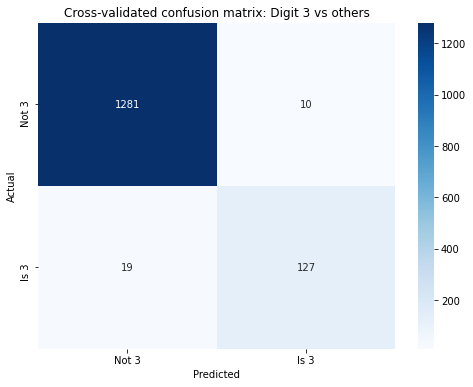


Classification Report:
              precision    recall  f1-score   support

       Not 3       0.99      0.99      0.99      1291
        Is 3       0.93      0.87      0.90       146

    accuracy                           0.98      1437
   macro avg       0.96      0.93      0.94      1437
weighted avg       0.98      0.98      0.98      1437



In [13]:
# Confusion matrix from the out-of-fold training predictions
print("\nConfusion Matrix:")
cm = confusion_matrix(y_train_binary, y_pred_binary)
print(cm)
print(f"\nTrue Negatives (TN):  {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP):  {cm[1, 1]}")

# Visualise confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not 3', 'Is 3'],
    yticklabels=['Not 3', 'Is 3']
)
plt.title('Cross-validated confusion matrix: Digit 3 vs others')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Show classification report
print("\nClassification Report:")
print(classification_report(
    y_train_binary,
    y_pred_binary,
    target_names=['Not 3', 'Is 3']
))


Step 6 used out-of-fold predictions from stratified cross-validation on the training data to demonstrate precision, recall and F1 in a context where class imbalance makes these metrics particularly important. The held-out test set remains untouched. Step 7 returns to the full 10-class digit recognition problem to demonstrate fair model comparison across multiple algorithms.

## Step 7: Fair model comparison

In [14]:
print("\nComparing multiple models on the full 10-class problem...")
print("All models use the same preprocessing and cross-validation setup.")
print("-" * 70)

# Define models with appropriate preprocessing
# Note: Decision Trees and Random Forest do not require scaling as they split on thresholds
# rather than distances. The scaler is included here for pipeline
# consistency in this demonstration but has no effect on performance.
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            C=grid_search_lr.best_params_['classifier__C'],
            solver='lbfgs',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier(
            n_neighbors=grid_search_knn.best_params_['classifier__n_neighbors'],
            weights=grid_search_knn.best_params_['classifier__weights']
        ))
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', DecisionTreeClassifier(
            max_depth=grid_search_dt.best_params_['classifier__max_depth'],
            min_samples_split=grid_search_dt.best_params_['classifier__min_samples_split'],
            min_samples_leaf=grid_search_dt.best_params_['classifier__min_samples_leaf'],
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(
            n_estimators=grid_search_rf.best_params_['classifier__n_estimators'],
            max_depth=grid_search_rf.best_params_['classifier__max_depth'],
            min_samples_split=grid_search_rf.best_params_['classifier__min_samples_split'],
            random_state=42
        ))
    ])
}
# Compare all models using cross-validation
print("\nCross-validation results (5-fold):")
print("=" * 70)

comparison_results = []

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    comparison_results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std Accuracy': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })

    print(f"\n{name}:")
    print(f"  Mean accuracy: {scores.mean():.3f}")
    print(f"  Std deviation: {scores.std():.3f}")
    print(f"  Range: {scores.min():.3f} to {scores.max():.3f}")

# Find and display best model
best_model_info = max(comparison_results, key=lambda x: x['Mean Accuracy'])

# The top models here are separated by far less than their standard
# deviations, so this "best" is the highest mean, not a meaningful winner.
print(f"\nHighest mean CV accuracy: {best_model_info['Model']} "
      f"({best_model_info['Mean Accuracy']:.3f})")



Comparing multiple models on the full 10-class problem...
All models use the same preprocessing and cross-validation setup.
----------------------------------------------------------------------

Cross-validation results (5-fold):

Logistic Regression:
  Mean accuracy: 0.969
  Std deviation: 0.009
  Range: 0.955 to 0.979

K-Nearest Neighbors:
  Mean accuracy: 0.975
  Std deviation: 0.014
  Range: 0.951 to 0.993

Decision Tree:
  Mean accuracy: 0.851
  Std deviation: 0.023
  Range: 0.819 to 0.875

Random Forest:
  Mean accuracy: 0.976
  Std deviation: 0.010
  Range: 0.965 to 0.993

Highest mean CV accuracy: Random Forest (0.976)



Model comparison summary:
              Model  Mean Accuracy  Std Accuracy      Min      Max
      Random Forest       0.976326      0.010441 0.965157 0.993056
K-Nearest Neighbors       0.974930      0.014192 0.951220 0.993056
Logistic Regression       0.969374      0.008666 0.954704 0.979094
      Decision Tree       0.851057      0.022533 0.818815 0.874564


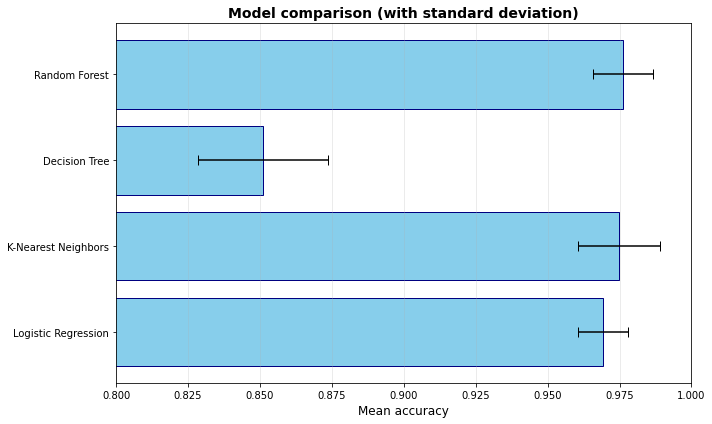

In [15]:
# Create a comparison dataframe
results_df = pd.DataFrame(comparison_results)
results_df = results_df.sort_values('Mean Accuracy', ascending=False)
print("\nModel comparison summary:")
print(results_df.to_string(index=False))

# Visualise comparison
plt.figure(figsize=(10, 6))
models_names = [r['Model'] for r in comparison_results]
means = [r['Mean Accuracy'] for r in comparison_results]
stds = [r['Std Accuracy'] for r in comparison_results]

plt.barh(models_names, means, xerr=stds, capsize=5, color='skyblue', edgecolor='navy')
plt.xlabel('Mean accuracy', fontsize=12)
plt.title('Model comparison (with standard deviation)', fontsize=14, fontweight='bold')
plt.xlim(0.8, 1.0)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 8: Final evaluation on the test set

In [16]:
print("\nNow that the best model has been identified through cross-validation,")
print("it is evaluated once on the held-out test set.")
print("-" * 70)

# Train best model on full training set
best_model_name = best_model_info['Model']
best_pipeline = models[best_model_name]


# cross_val_score clones the estimator internally, so this pipeline was
# never fitted during comparison. We now fit it on the full training set
# before the single, final test-set evaluation.
best_pipeline.fit(X_train, y_train)

# Predict on test set
y_pred_test = best_pipeline.predict(X_test)

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"\nFinal test set accuracy: {test_accuracy:.3f}")

# Show detailed classification report
print("\nDetailed classification report:")
print("=" * 70)
print(classification_report(y_test, y_pred_test))


Now that the best model has been identified through cross-validation,
it is evaluated once on the held-out test set.
----------------------------------------------------------------------

Final test set accuracy: 0.961

Detailed classification report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.94      0.93        36
           2       1.00      0.97      0.99        35
           3       0.95      0.97      0.96        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.9

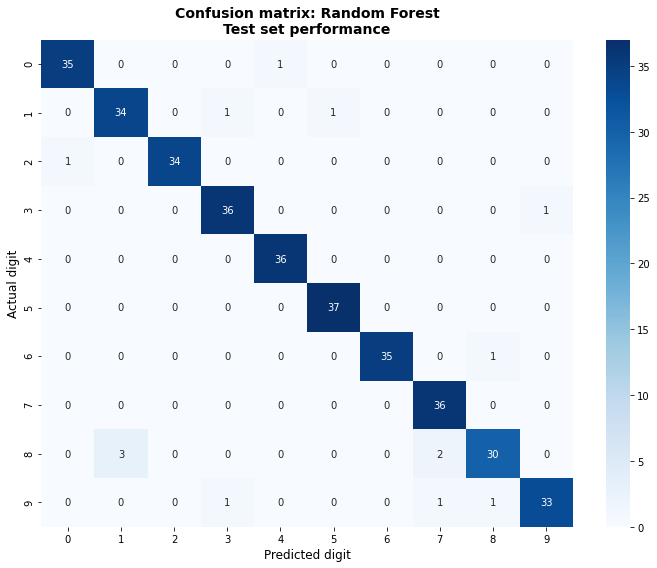

In [17]:
# Confusion matrix for all digits
cm_full = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion matrix: {best_model_name}\nTest set performance',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual digit', fontsize=12)
plt.xlabel('Predicted digit', fontsize=12)
plt.tight_layout()
plt.show()

---

**Key takeaways:**

1. Use cross-validation for more reliable model comparison and retain a held-out test set for final evaluation.
2. Hyperparameter tuning can improve performance, but its benefit should be assessed against the baseline cross-validation results.
3. For imbalanced data, look beyond accuracy – use precision, recall and F1.
4. Fair model comparison requires an identical setup for all models.
5. Evaluate on the test set exactly once, at the very end.

---

> **Note:** Results are fully reproducible with the fixed random seeds used in this notebook. They may differ slightly across different versions of scikit-learn due to changes in underlying implementations.
